In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
import numpy as np

# Решение задач с двумя параметрами

Метод **ступенчатого (покоординатного) спуска**. Девять задач из `zadachi_2param.pdf`.

Файл собран из `grid_search.ipynb`, `training.ipynb`, `Задачи 2 параметра.ipynb`: убраны дубли,
графики вынесены отдельно, детальная работа по температурному полю — в раздел 6.

Разделы: 1) метод → 2) функции задач → 3) решения спуском → 4) перебор по сетке (склад) →
5) графики задач (3D-поверхности) → 6) вилка: температурное поле.

## 1. Метод: ступенчатый (покоординатный) спуск

У функции двух переменных нет отрезка, который можно было бы поделить пополам. Зато можно
зафиксировать одну переменную и минимизировать по второй — одномерным методом (золотое сечение),
затем поменять переменные местами и повторить. Каждый такой шаг — «ступенька» вдоль координатной оси.

- `golden_section` — одномерный минимизатор, внутренняя подпрограмма.
- `make_func_along_x` / `make_func_along_y` — превращают функцию двух переменных в функцию одной
  при fixed-координате.
- `coordinate_descent` — внешний цикл: шаг по x при фиксированном y, затем шаг по y при фиксированном x.
  Остановка — когда сдвиг по обеим координатам меньше `eps`.
- `grid_search` — сплошной перебор сетки n × n. Применяется только в двух местах: к задаче о складе
  (раздел 4) и к температурному полю (раздел 6).

In [2]:

def golden_section(f, a, b, eps=1e-6, max_iter=200):
    '''Одномерный поиск минимума золотым сечением.
    Возвращает (x_opt, f_opt, итерации, вызовы функции).'''
    phi = (1 + 5 ** 0.5) / 2
    k1 = 1 - 1 / phi
    k2 = 1 / phi
    x1 = a + k1 * (b - a)
    x2 = a + k2 * (b - a)
    f1 = f(x1)
    f2 = f(x2)
    calls = 2
    it = 0
    for it in range(max_iter):
        if b - a < eps:
            break
        if f1 < f2:                 # минимум слева -> [a, x2]
            b = x2
            x2 = x1
            f2 = f1
            x1 = a + k1 * (b - a)
            f1 = f(x1)
            calls += 1
        else:                       # минимум справа -> [x1, b]
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + k2 * (b - a)
            f2 = f(x2)
            calls += 1
    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    calls += 1
    return x_opt, f_opt, it + 1, calls



def grid_search(f, bounds, n):
    '''Сплошной перебор сетки n x n. Возвращает (x, y, f, вызовы).'''
    (xa, xb), (ya, yb) = bounds
    xs = [xa + (xb - xa) * i / (n - 1) for i in range(n)]
    ys = [ya + (yb - ya) * i / (n - 1) for i in range(n)]
    best_x, best_y = xs[0], ys[0]
    best_f = f(best_x, best_y)
    calls = 0
    for y in ys:
        for x in xs:
            v = f(x, y)
            calls += 1
            if v < best_f:
                best_x, best_y, best_f = x, y, v
    return best_x, best_y, best_f, calls

In [3]:
def make_func_along_x(f, y_fixed):
    def g(x):
        return f(x, y_fixed)             
    return g

def make_func_along_y(f, x_fixed):
    def h(y):
        return f(x_fixed, y) 
    return h

def coordinate_descent(f, bounds, eps=1e-3, max_iter=1000):
    
    # Вычисляем середину границ для каждой координаты
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2

    converged = False 
    iteration_count = 0
    func_calls = 0  # счётчик вызовов f

    # Обёртка для подсчёта вызовов одномерной функции
    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y

        x_bounds, y_bounds = bounds[0], bounds[1]

        g_x = make_func_along_x(f, y) 
        x, _, _, _ = golden_section(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)

        h_y = make_func_along_y(f, x)
        y, _, _, _ = golden_section(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)

        iteration_count += 1

        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break  
            
    return x, y, converged, iteration_count, func_calls

## 2. Функции задач

Для каждой задачи — целевая функция двух переменных и прямоугольник поиска. Задачи на максимум
записаны со знаком минус (спуск ищет минимум). Задача 6 после подстановки связи сводится к одной
переменной.

In [4]:
# 1. Аквариум без крышки, V = 32 л. Из V = x*y*z выражаем x = 32/(y*z) и подставляем в площадь.
def f_1(y, z):
    return 32 / z + 64 / y + 2 * y * z


# 2. Посылка: длина + обхват <= 108, то есть c = 108 - 2*(a + b). Максимум объёма берём со знаком минус.
def f_2(a, b):
    return -(54 * a * b - a ** 2 * b - a * b ** 2)


# 3. МНК: подбор прямой y = k*x + b по пяти точкам; минимизируем сумму квадратов отклонений.
POINTS = [(1, 2), (2, 2), (3, 4), (4, 5), (5, 6)]
def f_3(k, b):
    return sum((k * x + b - y) ** 2 for x, y in POINTS)


# 4. Склад: сумма расстояний до A(0; 0), B(8; 0), C(4; 6).
def f_4(x, y):
    return (math.sqrt(x ** 2 + y ** 2)
            + math.sqrt((x - 8) ** 2 + y ** 2)
            + math.sqrt((x - 4) ** 2 + (y - 6) ** 2))


# 5. Два товара: прибыль P = 40x + 50y - x^2 - y^2 - xy; максимум берём со знаком минус.
def f_5(x, y):
    return -(40 * x + 50 * y - x ** 2 - y ** 2 - x * y)


# 6. Цех: Q = sqrt(L*K) = 200 => K = 40000/L. Затраты 16L + 4K = 16L + 160000/L — одна переменная.
def f_6(L):
    return 16 * L + 160000 / L


# 7. Три слоя: x1, x2 — абсциссы точек преломления на границах слоёв.
def f_7(x1, x2):
    return (math.sqrt(4 + x1 ** 2) / 4
            + math.sqrt((x2 - x1) ** 2 + 9) / 2
            + math.sqrt((10 - x2) ** 2 + 4) / 3)


# 8. Ящик: вершина на плоскости x/6 + y/4 + z/3 = 1 => x = 6 - 1.5*y - 2*z; максимум объёма — минус.
def f_8(y, z):
    return -(6 * y * z - 1.5 * y ** 2 * z - 2 * y * z ** 2)


# 9. Температурное поле T = x^3 + y^3 - 3xy. Подробный разбор — в разделе 6.
def f_9(x, y):
    return x ** 3 + y ** 3 - 3 * x * y

## 3. Решения задач ступенчатым спуском

Каждую задачу решаем `coordinate_descent` при `eps = 1e-3`. Точки, найденные здесь, используются
дальше и в переборе (раздел 4), и на графиках (раздел 5). Задача 6 одномерная — её разбор отдельно
в конце раздела.

In [5]:
import math

EPS = 1e-3

# (номер, название, функция, прямоугольник поиска, аналитическая точка, ответ в терминах задачи)
TASKS = [
    (1, "Аквариум", f_1, [[0.0, 5.0], [0.0, 5.0]], (4.0, 2.0),
     lambda x, y: f"длина {32 / (x * y):.3f}, ширина {x:.3f}, высота {y:.3f}"),
    (2, "Посылка", f_2, [[0.0, 40.0], [0.0, 40.0]], (18.0, 18.0),
     lambda a, b: f"a={a:.3f}, b={b:.3f}, c={108 - 2 * (a + b):.3f}, "
                  f"V={a * b * (108 - 2 * (a + b)):.2f}"),
    (3, "МНК", f_3, [[-2.0, 3.0], [-2.0, 3.0]], (1.1, 0.5),
     lambda k, b: f"y = {k:.3f}x + {b:.3f}, S={f_3(k, b):.4f}"),
    (4, "Склад", f_4, [[0.0, 8.0], [0.0, 6.0]], (4.0, 4 / math.sqrt(3)),
     lambda x, y: f"центр ({x:.3f}; {y:.3f}), сумма расстояний {f_4(x, y):.4f}"),
    (5, "Два товара", f_5, [[0.0, 30.0], [0.0, 30.0]], (10.0, 20.0),
     lambda x, y: f"x={x:.3f}, y={y:.3f} тыс., прибыль {-f_5(x, y):.3f}"),
    (7, "Три слоя", f_7, [[0.0, 10.0], [0.0, 10.0]], None,
     lambda x1, x2: f"x1={x1:.4f}, x2={x2:.4f}, время {f_7(x1, x2):.4f}"),
    (8, "Ящик", f_8, [[0.0, 2.5], [0.5, 1.5]], (4 / 3, 1.0),
     lambda y, z: f"{6 - 1.5 * y - 2 * z:.3f} x {y:.3f} x {z:.3f}, "
                  f"V={(6 - 1.5 * y - 2 * z) * y * z:.3f}"),
    (9, "Температура", f_9, [[0.5, 1.5], [0.5, 1.5]], (1.0, 1.0),
     lambda x, y: f"минимум ({x:.3f}; {y:.3f}), T={f_9(x, y):.3f}"),
]


def solve_all(tasks, eps=EPS):
    '''Прогоняет спуск по всем задачам. Возвращает {номер: (x, y)}.'''
    res = {}
    for num, name, f, bounds, ref, answer in tasks:
        x, y, conv, it, calls = coordinate_descent(f, bounds, eps=eps)
        res[num] = (x, y)
    return res


results = solve_all(TASKS)

### Автоматическая генерация таблицы

Функция `generate_table` сама прогоняет спуск по всем задачам и собирает markdown-таблицу.
Для обновления данных — перезапустите ячейку. Точность `eps = 1e-3`.

In [6]:
from IPython.display import Markdown, display


def generate_table(tasks, eps=EPS):
    lines = [
        "| № | Задача | x | y | f(x, y) | Сошлось | Итераций | Вызовов "
        "| Аналитика (x; y) | Ответ в терминах задачи |",
        "|:---:|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|",
    ]
    for num, name, f, bounds, ref, answer in tasks:
        x, y, conv, it, calls = coordinate_descent(f, bounds, eps=eps)
        ref_str = f"({ref[0]:.3f}; {ref[1]:.3f})" if ref is not None else "—"
        lines.append(
            f"| {num} | {name} | {x:.3f} | {y:.3f} | {f(x, y):.3f} "
            f"| {'да' if conv else 'нет'} | {it} | {calls} | {ref_str} | {answer(x, y)} |"
        )
    display(Markdown("\n".join(lines)))


generate_table(TASKS)

| № | Задача | x | y | f(x, y) | Сошлось | Итераций | Вызовов | Аналитика (x; y) | Ответ в терминах задачи |
|:---:|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| 1 | Аквариум | 4.000 | 2.000 | 48.000 | да | 7 | 294 | (4.000; 2.000) | длина 4.000, ширина 4.000, высота 2.000 |
| 2 | Посылка | 18.000 | 18.000 | -5832.000 | да | 7 | 364 | (18.000; 18.000) | a=18.000, b=18.000, c=36.000, V=11664.00 |
| 3 | МНК | 1.100 | 0.499 | 0.700 | да | 2 | 84 | (1.100; 0.500) | y = 1.100x + 0.499, S=0.7000 |
| 4 | Склад | 4.000 | 2.309 | 12.928 | да | 2 | 88 | (4.000; 2.309) | центр (4.000; 2.309), сумма расстояний 12.9282 |
| 5 | Два товара | 10.000 | 20.000 | -700.000 | да | 8 | 400 | (10.000; 20.000) | x=10.000, y=20.000 тыс., прибыль 700.000 |
| 7 | Три слоя | 6.325 | 7.953 | 4.319 | да | 19 | 874 | — | x1=6.3252, x2=7.9526, время 4.3190 |
| 8 | Ящик | 1.333 | 1.000 | -2.667 | да | 2 | 76 | (1.333; 1.000) | 2.000 x 1.333 x 1.000, V=2.667 |
| 9 | Температура | 1.000 | 1.000 | -1.000 | да | 1 | 36 | (1.000; 1.000) | минимум (1.000; 1.000), T=-1.000 |

### Задача 6 (одна переменная)

Цех: после подстановки связи $K = 40000/L$ затраты становятся функцией одной переменной
$16L + 160000/L$, и её решает золотое сечение. В таблицу эта задача не входит — она одномерная.

In [7]:
L, f_L, it6, calls6 = golden_section(f_6, 1.0, 500.0, eps=EPS)
K = 40000 / L
print(f"L = {L:.4f}, K = {K:.4f}, затраты = {16 * L + 4 * K:.4f}, "
      f"итераций = {it6}, вызовов = {calls6}")

L = 99.9998, K = 400.0009, затраты = 3200.0000, итераций = 29, вызовов = 31


## 4. Перебор по сетке: задача о складе

Сплошной перебор `grid_search` нужен не как метод решения, а как проверка: он берёт сетку n × n и
возвращает лучшую точку. Точность ограничена шагом сетки, а число вызовов функции равно n² — растёт
как квадрат. Ниже — прогон по задаче о складе и та же поверхность с обеими найденными точками.

Перебор 300 x 300: точка (3.9866; 2.3077), суммарное расстояние = 12.9282, вызовов = 90000
Ступенчатый спуск:  точка (4.0003; 2.3095), суммарное расстояние = 12.9282


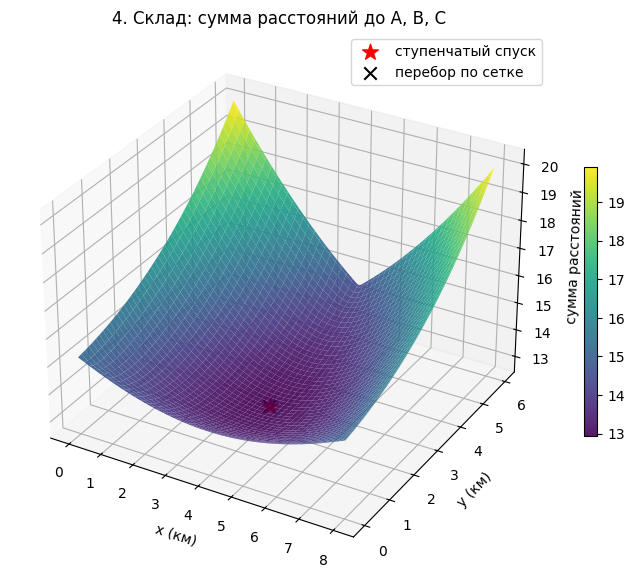

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Перебор по сетке для задачи о складе
gx, gy, gv, gcalls = grid_search(f_4, [[0.0, 8.0], [0.0, 6.0]], 300)
x4, y4 = results[4]
print(f"Перебор 300 x 300: точка ({gx:.4f}; {gy:.4f}), суммарное расстояние = {gv:.4f}, "
      f"вызовов = {gcalls}")
print(f"Ступенчатый спуск:  точка ({x4:.4f}; {y4:.4f}), суммарное расстояние = {f_4(x4, y4):.4f}")

# Поверхность суммы расстояний
xs = np.linspace(0.0, 8.0, 140)
ys = np.linspace(0.0, 6.0, 140)
X, Y = np.meshgrid(xs, ys)
Z = np.vectorize(f_4)(X, Y)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.scatter([x4], [y4], [f_4(x4, y4)], color='red', s=140, marker='*', label='ступенчатый спуск')
ax.scatter([gx], [gy], [gv], color='black', s=80, marker='x', label='перебор по сетке')
ax.set_xlabel('x (км)')
ax.set_ylabel('y (км)')
ax.set_zlabel('сумма расстояний')
ax.set_title('4. Склад: сумма расстояний до A, B, C')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.show()

## 5. Графики задач

Для каждой задачи — поверхность самой величины (площади, объёма, прибыли, времени, затрат) и точка,
найденная ступенчатым спуском (красная звезда). Задача 3 (МНК) — её собственный график: облако точек
и подогнанная прямая. Задача 4 — в разделе 4, задача 9 — в разделе 6.

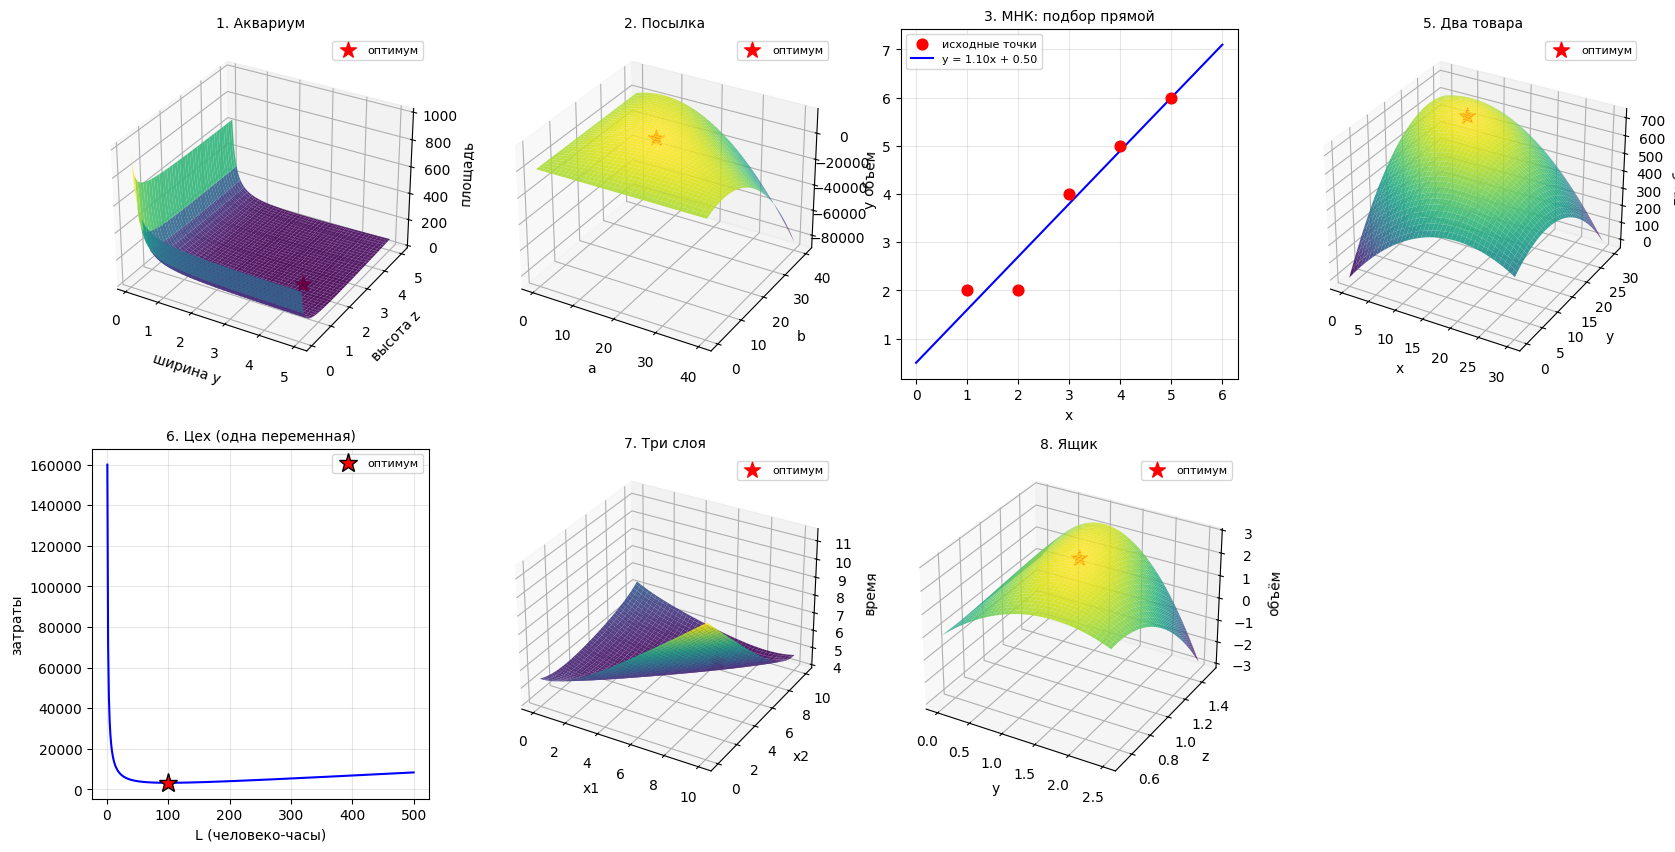

In [9]:
import matplotlib.pyplot as plt
import numpy as np


# display-функции: показываем саму величину задачи, а не её минус (только для рисования)
def show_1(y, z):
    return 32 / z + 64 / y + 2 * y * z                    # площадь аквариума


def show_2(a, b):
    return a * b * (108 - 2 * (a + b))                    # объём посылки


def show_5(x, y):
    return 40 * x + 50 * y - x ** 2 - y ** 2 - x * y      # прибыль


def show_7(x1, x2):
    return f_7(x1, x2)                                    # время в пути


def show_8(y, z):
    return y * z * (6 - 1.5 * y - 2 * z)                  # объём ящика


def surface_task(ax, f, bounds, point, title, xlabel, ylabel, zlabel):
    (xa, xb), (ya, yb) = bounds
    us = np.linspace(xa, xb, 120)
    vs = np.linspace(ya, yb, 120)
    U, V = np.meshgrid(us, vs)
    Z = np.vectorize(f)(U, V)
    ax.plot_surface(U, V, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    pu, pv = point
    ax.scatter([pu], [pv], [f(pu, pv)], color='red', s=140, marker='*', label='оптимум')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.legend(fontsize=8)


fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(2, 4, 1, projection='3d')
surface_task(ax1, show_1, [[0.1, 5.0], [0.1, 5.0]], results[1],
             '1. Аквариум', 'ширина y', 'высота z', 'площадь')

ax2 = fig.add_subplot(2, 4, 2, projection='3d')
surface_task(ax2, show_2, [[0.1, 40.0], [0.1, 40.0]], results[2],
             '2. Посылка', 'a', 'b', 'объём')

ax3 = fig.add_subplot(2, 4, 3)
k3, b3 = results[3]
ax3.scatter([p[0] for p in POINTS], [p[1] for p in POINTS], color='red', s=60, zorder=5,
            label='исходные точки')
xs_line = [min(p[0] for p in POINTS) - 1, max(p[0] for p in POINTS) + 1]
ax3.plot(xs_line, [k3 * x + b3 for x in xs_line], 'b-', label=f'y = {k3:.2f}x + {b3:.2f}')
ax3.set_title('3. МНК: подбор прямой', fontsize=10)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

ax5 = fig.add_subplot(2, 4, 4, projection='3d')
surface_task(ax5, show_5, [[0.0, 30.0], [0.0, 30.0]], results[5],
             '5. Два товара', 'x', 'y', 'прибыль')

ax6 = fig.add_subplot(2, 4, 5)
Ls = np.linspace(1.0, 500.0, 400)
ax6.plot(Ls, [f_6(L) for L in Ls], 'b-')
ax6.plot(L, f_6(L), 'r*', markersize=14, markeredgecolor='black', label='оптимум')
ax6.set_title('6. Цех (одна переменная)', fontsize=10)
ax6.set_xlabel('L (человеко-часы)')
ax6.set_ylabel('затраты')
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=8)

ax7 = fig.add_subplot(2, 4, 6, projection='3d')
surface_task(ax7, show_7, [[0.0, 10.0], [0.0, 10.0]], results[7],
             '7. Три слоя', 'x1', 'x2', 'время')

ax8 = fig.add_subplot(2, 4, 7, projection='3d')
surface_task(ax8, show_8, [[0.0, 2.5], [0.5, 1.5]], results[8],
             '8. Ящик', 'y', 'z', 'объём')

ax9 = fig.add_subplot(2, 4, 8)
ax9.axis('off')

plt.show()

## 6. Отдельная вилка: температурное поле $T(x, y) = x^3 + y^3 - 3xy$

Эта задача отличается от остальных: у неё **две критические точки**, и не всякая из них — минимум.
Спуск ищет только минимум, а седловую точку найти этим методом нельзя в принципе. Поэтому здесь
сначала аналитика (частные производные и гессиан), затем численное подтверждение минимума и
отдельный эксперимент с областью около седла.

### 6.1. Аналитическое решение

$$ \frac{\partial T}{\partial x} = 3x^2 - 3y = 0 \;\Rightarrow\; y = x^2 $$
$$ \frac{\partial T}{\partial y} = 3y^2 - 3x = 0 \;\Rightarrow\; x = y^2 $$

Подстановка даёт $x = x^4$, то есть $x(x^3 - 1) = 0$: $x = 0$ или $x = 1$.
Критические точки — **(0; 0)** и **(1; 1)**.

Тип точки определяет матрица вторых производных (гессиан):

$$ H = \begin{pmatrix} 6x & -3 \\ -3 & 6y \end{pmatrix}, \qquad \det H = 36xy - 9 $$

- **(0; 0):** $\det H = -9 < 0$ → **седло**;
- **(1; 1):** $\det H = 27 > 0$, $\partial^2 T/\partial x^2 = 6 > 0$ → **локальный минимум**, $T = -1$.

In [10]:
def dT_dx(x, y):
    return 3 * x ** 2 - 3 * y


def dT_dy(x, y):
    return 3 * y ** 2 - 3 * x


def hessian(x, y):
    return [[6 * x, -3], [-3, 6 * y]]


def det2(M):
    return M[0][0] * M[1][1] - M[0][1] * M[1][0]


for cx, cy in [(0.0, 0.0), (1.0, 1.0)]:
    H = hessian(cx, cy)
    d = det2(H)
    if d < 0:
        kind = "седло"
    elif H[0][0] > 0:
        kind = "локальный минимум"
    else:
        kind = "локальный максимум"
    print(f"Точка ({cx:.0f}; {cy:.0f}): T = {f_9(cx, cy):.3f}, det H = {d:.1f}, "
          f"d2T/dx2 = {H[0][0]:.1f}  ->  {kind}")

print("\nПроверка градиента в критических точках:")
for cx, cy in [(0.0, 0.0), (1.0, 1.0)]:
    print(f"  ({cx:.0f}; {cy:.0f}): dT/dx = {dT_dx(cx, cy):.1e}, dT/dy = {dT_dy(cx, cy):.1e}")

Точка (0; 0): T = 0.000, det H = -9.0, d2T/dx2 = 0.0  ->  седло
Точка (1; 1): T = -1.000, det H = 27.0, d2T/dx2 = 6.0  ->  локальный минимум

Проверка градиента в критических точках:
  (0; 0): dT/dx = 0.0e+00, dT/dy = 0.0e+00
  (1; 1): dT/dx = 0.0e+00, dT/dy = 0.0e+00


### 6.2. Таблица значений T в узлах сетки

Полезно перед построением карты: видно, что значения около (1; 1) — наименьшие в центральной
области, а к углам функция уходит вниз неограниченно.

In [11]:
x_list = [-2, -1, 0, 1, 2]
y_list = [-2, -1, 0, 1, 2]

print("  x \\ y" + "".join(f"{y:>7}" for y in y_list))
for x in x_list:
    row = "".join(f"{x ** 3 + y ** 3 - 3 * x * y:>7}" for y in y_list)
    print(f"{x:>5}  {row}")

  x \ y     -2     -1      0      1      2
   -2      -28    -15     -8     -1     12
   -1      -15     -5     -1      3     13
    0       -8     -1      0      1      8
    1       -1      3      1     -1      3
    2       12     13      8      3      4


### 6.3. Карта поля и критические точки

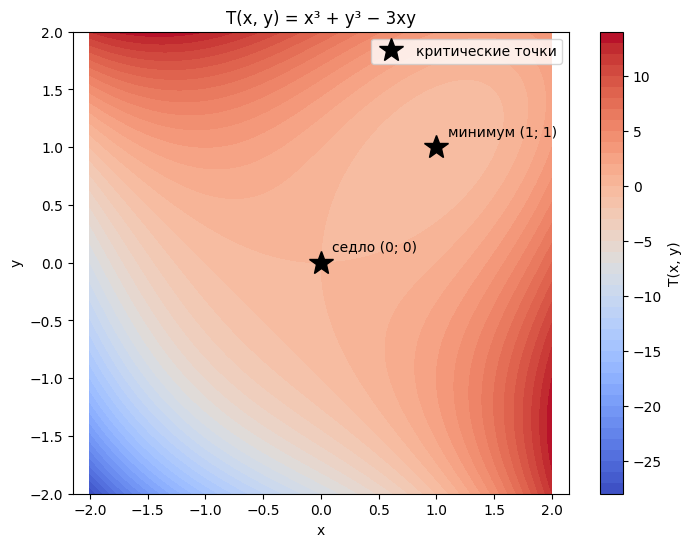

In [12]:
x = np.linspace(-2, 2, 300)
y = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x, y)
T = X ** 3 + Y ** 3 - 3 * X * Y

plt.figure(figsize=(8, 6))
cf = plt.contourf(X, Y, T, levels=50, cmap='coolwarm')
plt.colorbar(cf, label='T(x, y)')
plt.plot([0, 1], [0, 1], 'k*', markersize=18, label='критические точки')
plt.annotate('седло (0; 0)', (0, 0), textcoords='offset points', xytext=(8, 8))
plt.annotate('минимум (1; 1)', (1, 1), textcoords='offset points', xytext=(8, 8))
plt.xlabel('x')
plt.ylabel('y')
plt.title('T(x, y) = x³ + y³ − 3xy')
plt.axis('equal')
plt.legend()
plt.show()

### 6.4. Значения T поверх карты

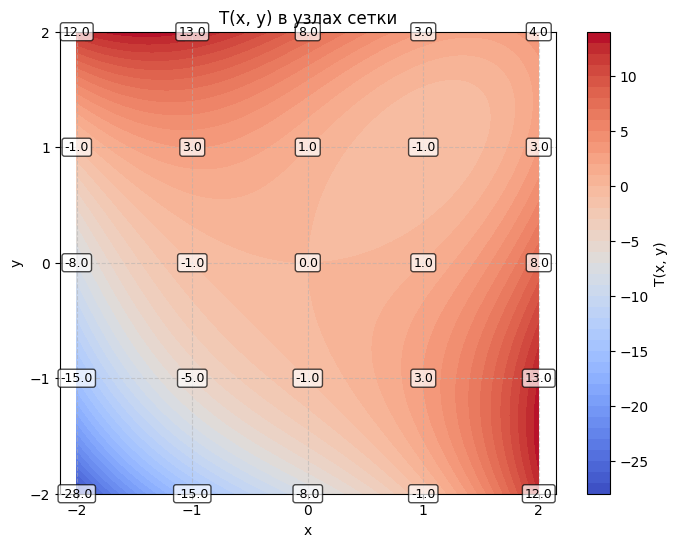

In [13]:
plt.figure(figsize=(8, 6))
cf = plt.contourf(X, Y, T, levels=50, cmap='coolwarm')
plt.colorbar(cf, label='T(x, y)')

for xv in range(-2, 3):
    for yv in range(-2, 3):
        t = xv ** 3 + yv ** 3 - 3 * xv * yv
        plt.text(xv, yv, f'{t:.1f}', ha='center', va='center', fontsize=9, color='black',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.xticks(range(-2, 3))
plt.yticks(range(-2, 3))
plt.xlabel('x')
plt.ylabel('y')
plt.title('T(x, y) в узлах сетки')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 6.5. Поверхность в 3D

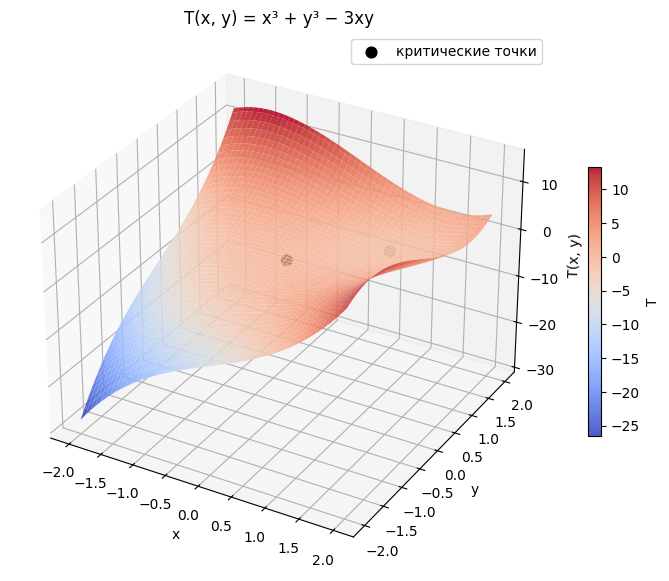

In [14]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
T = X ** 3 + Y ** 3 - 3 * X * Y

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, T, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax.scatter([0, 1], [0, 1], [0, -1], color='black', s=60, label='критические точки')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('T(x, y)')
ax.set_title('T(x, y) = x³ + y³ − 3xy')
fig.colorbar(surf, ax=ax, shrink=0.5, label='T')
ax.legend()
plt.show()

### 6.6. Перебор по сетке для температурного поля

Как и для задачи о складе, перебор здесь — проверка, а не метод. Важно, на каком прямоугольнике
его запускать: на большом он находит не минимум, а край области.

Сетка 200 x 200 на [-2, 2]^2: точка (-2.0000; -2.0000), T = -28.0000, вызовов = 40000
Сетка 200 x 200 на [ 0, 2]^2: точка (0.9950; 0.9950), T = -0.9999, вызовов = 40000

На большом прямоугольнике перебор уходит в угол (-2; -2): там T всего ниже,
но это край области, а не критическая точка. На [0, 2]^2 перебор попадает в минимум (1; 1).


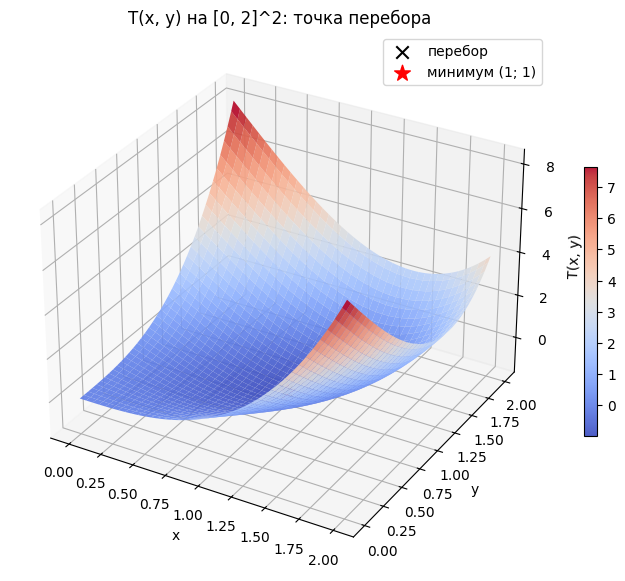

In [15]:
N = 200

gx1, gy1, gv1, gc1 = grid_search(f_9, [[-2.0, 2.0], [-2.0, 2.0]], N)
gx2, gy2, gv2, gc2 = grid_search(f_9, [[0.0, 2.0], [0.0, 2.0]], N)

print(f"Сетка {N} x {N} на [-2, 2]^2: точка ({gx1:.4f}; {gy1:.4f}), T = {gv1:.4f}, вызовов = {gc1}")
print(f"Сетка {N} x {N} на [ 0, 2]^2: точка ({gx2:.4f}; {gy2:.4f}), T = {gv2:.4f}, вызовов = {gc2}")
print()
print("На большом прямоугольнике перебор уходит в угол (-2; -2): там T всего ниже,")
print("но это край области, а не критическая точка. На [0, 2]^2 перебор попадает в минимум (1; 1).")

# 3D-поверхность на [0, 2]^2 с точкой, найденной перебором
xs = np.linspace(0.0, 2.0, 120)
ys = np.linspace(0.0, 2.0, 120)
X, Y = np.meshgrid(xs, ys)
T = X ** 3 + Y ** 3 - 3 * X * Y

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, T, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax.scatter([gx2], [gy2], [gv2], color='black', s=80, marker='x', label='перебор')
ax.scatter([1.0], [1.0], [-1.0], color='red', s=140, marker='*', label='минимум (1; 1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('T(x, y)')
ax.set_title('T(x, y) на [0, 2]^2: точка перебора')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.show()

### 6.7. Что делает спуск около седла

Запускаем `coordinate_descent` из маленького квадрата вокруг (0; 0) и из квадрата около минимума.
Первый прогон **не остаётся** в (0; 0): спуск уходит к границе области, где T продолжает падать.
Это и есть причина, по которой седло нельзя найти спуском — только аналитически.

In [16]:
# Спуск из квадрата вокруг седла (0; 0)
x_s, y_s, conv_s, it_s, calls_s = coordinate_descent(f_9, [[-0.1, 0.1], [-0.1, 0.1]], eps=EPS)
print("Спуск из квадрата вокруг седла (−0.1 .. 0.1):")
print(f"  точка ({x_s:.4f}; {y_s:.4f}), T = {f_9(x_s, y_s):.4f}, "
      f"сошлось = {conv_s}, итераций = {it_s}, вызовов = {calls_s}")
print("  (0; 0) не является минимумом: метод сходит с седла и упирается в границу области.")

# Спуск из квадрата около минимума
x_m, y_m, conv_m, it_m, calls_m = coordinate_descent(f_9, [[0.5, 2.0], [0.5, 2.0]], eps=EPS)
print()
print("Спуск из квадрата около минимума (0.5 .. 2.0):")
print(f"  точка ({x_m:.4f}; {y_m:.4f}), T = {f_9(x_m, y_m):.4f}, "
      f"сошлось = {conv_m}, итераций = {it_m}, вызовов = {calls_m}")

Спуск из квадрата вокруг седла (−0.1 .. 0.1):
  точка (-0.0997; -0.0997), T = -0.0318, сошлось = True, итераций = 2, вызовов = 60
  (0; 0) не является минимумом: метод сходит с седла и упирается в границу области.

Спуск из квадрата около минимума (0.5 .. 2.0):
  точка (1.0001; 1.0001), T = -1.0000, сошлось = True, итераций = 6, вызовов = 228


# 7. Параболоид

In [17]:
def paraboloid(x, y):
    return x ** 2 + y ** 2

Для любой точки $(x, y)$ и угла поворота $\theta$:
$$x' = x\cos\theta - y\sin\theta$$
$$y' = x\sin\theta + y\cos\theta$$
Пример. Повернём точку $(2, 0)$ на 90° ($\cos90°=0$, $\sin90°=1$):
$$x' = 2\cdot 0 - 0\cdot 1 = 0,\qquad y' = 2\cdot 1 + 0\cdot 0 = 2.$$


In [18]:
p = [3, 1]
angle = math.radians(30)
x1 = 3 * math.cos(angle) - 1 * math.sin(angle)
y1 = 3 * math.sin(angle) + 1 * math.cos(angle)
p_new = [x1, y1]
print(p_new)

[2.098076211353316, 2.3660254037844384]


Формула $y = x^2$ задаёт точки: для каждого $t$ есть точка $(t,\ t^2)$: Подставляем нашу точку параболы $(t,\ t^2)$:
$$x' = t\cos\theta - t^2\sin\theta,\qquad y' = t\sin\theta + t^2\cos\theta.$$
Всё. У тебя есть формула повёрнутой параболы, зависящая от параметра $t$.
3. Пример: поворот на 45°
$\cos45°=\sin45°=0{,}7071$. Тогда
$$x' = 0{,}7071\,(t - t^2),\qquad y' = 0{,}7071\,(t + t^2).$$
Считаем несколько точек:
$t$
0
0.5
1
2
−1


In [19]:
def parabola(x):
    return x ** 2

x_values = [-1, 0, 1]
angle_degrees = 45
angle_radians = math.radians(angle_degrees)

rotated_points = []#повернутые точки

#поворачиваем каждую точку
for x in x_values:
    y = parabola(x)
    
    x_new = x * math.cos(angle_radians) - y * math.sin(angle_radians)
    y_new = x * math.sin(angle_radians) + y * math.cos(angle_radians)
    
    rotated_points.append((x_new, y_new))

print("Повёрнутые точки (x, y):")
for point in rotated_points:
    print(f"({point[0]:.3f}, {point[1]:.3f})")




Повёрнутые точки (x, y):
(-1.414, 0.000)
(0.000, 0.000)
(0.000, 1.414)


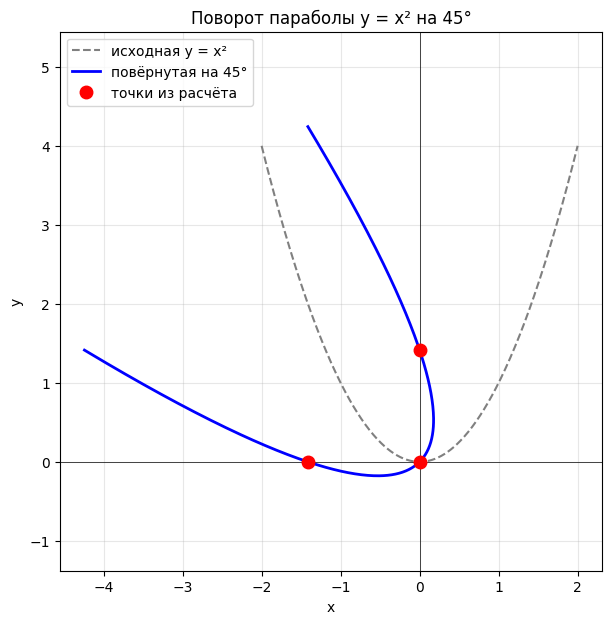

In [20]:

# тот же угол, что в расчёте выше
angle_radians = math.radians(45)

# плотный набор t, чтобы кривая была видна целиком
t = np.linspace(-2.0, 2.0, 400)
y_par = parabola(t)

# та же формула поворота, что и для точек
x_rot = t * math.cos(angle_radians) - y_par * math.sin(angle_radians)
y_rot = t * math.sin(angle_radians) + y_par * math.cos(angle_radians)

plt.figure(figsize=(7, 7))
plt.plot(t, y_par, '--', color='gray', label='исходная y = x²')
plt.plot(x_rot, y_rot, 'b-', linewidth=2, label='повёрнутая на 45°')

# три точки из расчёта выше
rp = np.array(rotated_points)
plt.plot(rp[:, 0], rp[:, 1], 'ro', markersize=9, zorder=5, label='точки из расчёта')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Поворот параболы y = x² на 45°')
plt.legend()
plt.show()

Параболоид задаётся точками $(u,\ v,\ u^2+v^2)$ — то есть поверхность «чаша».
Чтобы повернуть, к каждой точке применяют матрицу $3\times3$. Но здесь появляется новое: надо указать ось поворота, одного угла мало.
- Поворот вокруг оси $z$ — а параболоид $z = x^2+y^2$ симметричен относительно $z$! Значит, при повороте вокруг $z$ не изменится ничего: он переходит сам в себя. Это и есть «тело вращения».
- Поворот вокруг оси $x$ — вот он наклоняет чашу. Точка $(u, v, z)$, где $z = u^2+v^2$, переходит в
$$x' = u,\qquad y' = v\cos\theta - z\sin\theta,\qquad z' = v\sin\theta + z\cos\theta.$$
- Поворот вокруг оси $y$ — аналогично, но наклоняется в другую сторону.
Проверка смысла: при $\theta = 90°$ получаем $y' = -z$, $z' = v$ — чаша «ложится на бок», ось симметрии уходит в горизонталь.

In [21]:
coordinate_values = [(-1, -1), (0, 0), (1, 1)] #values of x, y
angle_degrees = 45
angle_radians = math.radians(angle_degrees)

rotated_points = []#повернутые точки

for x, y in coordinate_values:
    # исходная z
    z = paraboloid(x, y)    

    x_new = x  # Координата х не меняется при вращении вокруг оси X
    y_new = y * math.cos(angle_radians) - z * math.sin(angle_radians)
    z_new = y * math.sin(angle_radians) + z * math.cos(angle_radians)
    
    # новая точка
    rotated_points.append((x_new, y_new, z_new))

print("Повёрнутые точки (x, y, z):")
for point in rotated_points:
    print(f"({point[0]:.2f}, {point[1]:.2f}, {point[2]:.2f})")


Повёрнутые точки (x, y, z):
(-1.00, -2.12, 0.71)
(0.00, 0.00, 0.00)
(1.00, -0.71, 2.12)


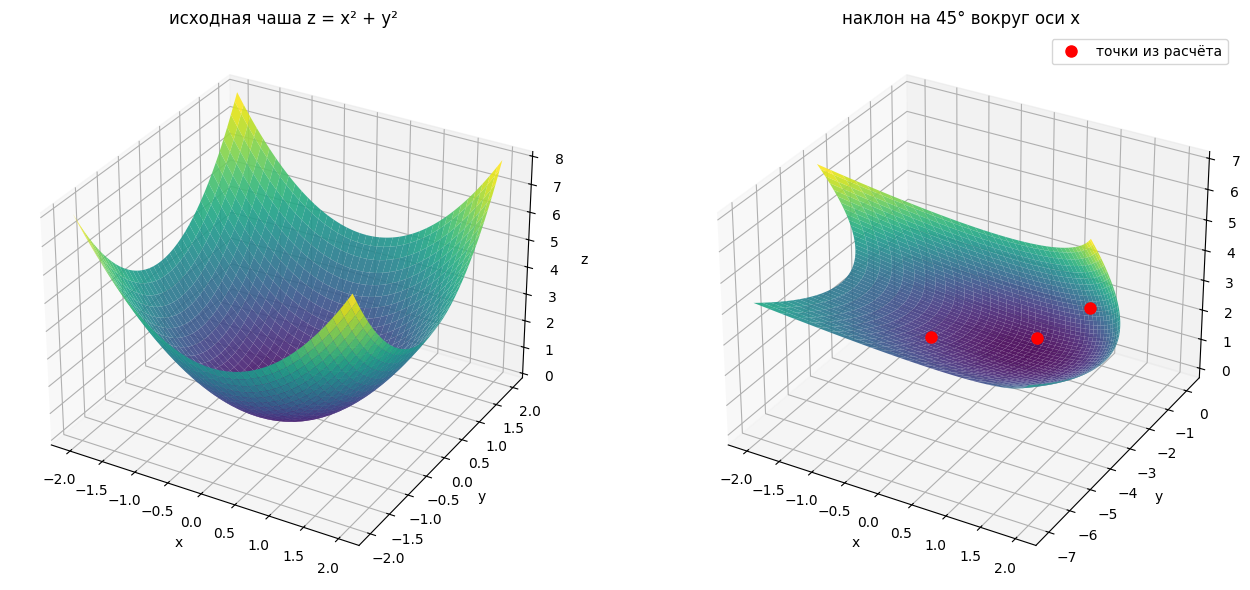

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# тот же угол, что в расчёте выше
theta = math.radians(45)
ct, st = math.cos(theta), math.sin(theta)

# исходная чаша z = x^2 + y^2
u = np.linspace(-2.0, 2.0, 120)
v = np.linspace(-2.0, 2.0, 120)
U, V = np.meshgrid(u, v)
Z = paraboloid(U, V)

# та же формула поворота вокруг оси x, что и для точек
X_rot = U
Y_rot = V * ct - Z * st
Z_rot = V * st + Z * ct

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(U, V, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('исходная чаша z = x² + y²')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_rot, Y_rot, Z_rot, cmap='viridis', edgecolor='none', alpha=0.9)

# три точки из расчёта выше
rp = np.array(rotated_points)
ax2.plot(rp[:, 0], rp[:, 1], rp[:, 2], 'ro', markersize=8, zorder=5, label='точки из расчёта')
ax2.set_title('наклон на 45° вокруг оси x')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.legend()

plt.tight_layout()
plt.show()

#### Ступенчатый спуск для параболоида

In [23]:
x, y, converged, iteration, func_calls = coordinate_descent(paraboloid, [[0.0, 1.0], [0.0, 1.0]], eps=1e-3, max_iter=1000)

print(f"Оптимальная точка: x = {x:.3f}, y = {y:.3f}")
print(f"Значение ф-ции: {paraboloid(x, y):.3f}")
print(f"Сходимость достигнута: {converged}")
print(f"Количество итераций: {iteration}, вызовов функции: {func_calls}")

Оптимальная точка: x = 0.000, y = 0.000
Значение ф-ции: 0.000
Сходимость достигнута: True
Количество итераций: 2, вызовов функции: 72


In [24]:
theta = math.radians(45)  # Угол поворота 45 градусов
ct = math.cos(theta)
st = math.sin(theta)

# поворот по оси Х 
# z = y * math.sin(theta) + (x**2 + y**2).cos(theta)

def rotated_paraboloid(x, y):
    return y * st + (x**2 + y**2) * ct

In [25]:
x_opt, y_opt, converged, iteration, func_calls = coordinate_descent(rotated_paraboloid, [[-1.0, 1.0], [-1.0, 1.0]], eps=1e-3)
z_opt = rotated_paraboloid(x_opt, y_opt)

print(f"Оптимальная точка: x = {x_opt:.3f}, y = {y_opt:.3f}")
print(f"Значение ф-ции (повёрнутой): {z_opt:.3f}")
print(f"Сходимость достигнута: {converged}")
print(f"Количество итераций: {iteration}, вызовов функции: {func_calls}")

# проверка подстановкой: в настоящей точке экстремума производные близки к нулю
dz_dx = 2 * x_opt * ct
dz_dy = st + 2 * y_opt * ct
print(f"Производные в точке: dz/dx = {dz_dx:.4f}, dz/dy = {dz_dy:.4f}")
print("Обе близки к нулю — это внутренняя точка, а не край области.")

Оптимальная точка: x = 0.000, y = -0.500
Значение ф-ции (повёрнутой): -0.177
Сходимость достигнута: True
Количество итераций: 2, вызовов функции: 76
Производные в точке: dz/dx = 0.0004, dz/dy = -0.0003
Обе близки к нулю — это внутренняя точка, а не край области.


Вывод: При наклоне параболоида минимум функции высоты смещается с геометрического дна на боковую поверхность, при этом само дно остаётся неподвижным, потому что лежит на оси вращени х.